In [1]:
import os
import pickle
import numpy as np
import random
import torch
import config
from models import GCN, GIN, GraphSAGE, GatedGCN, AGNN, ARMA
from torch_geometric.explain import Explainer, GNNExplainer

In [42]:
def getBatchesDataset(path, batchsize=100):
    filebatches = [] # list of filenames
    
    subdirs, dirs, files = os.walk(qsm_path).__next__()
    random.shuffle(files)
    file_length = len(files)
    num_batches = int(np.ceil(file_length/batchsize))
    filebatches = [files[i:i+num_batches] for i in range(0, len(files), num_batches)]
    print(filebatches)
        
qsm_path = './pickle/obj2/'
getBatchesDataset(qsm_path,3)

[['1_2023-01-09_17_2_18_000095.pickle', '1_2023-01-09_17_2_18_000096.pickle', '1_2023-01-09_17_2_18_000092.pickle'], ['1_2023-01-09_17_2_18_000098.pickle', '1_2023-01-09_17_2_18_000091.pickle', '1_2023-01-09_17_2_18_000097.pickle'], ['1_2023-01-09_17_2_18_000090.pickle']]


In [2]:
data_path = './2023-01-16_44_000327.pickle'
model_path = './models/GatedGCN.pth'
gcn_path = './models/GCN.pth'
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

with open(data_path, 'rb') as f:  
    data = pickle.load(f) 
    
model = GatedGCN(
    in_channel=72, 
    n_convs=config.gated_num_convolutional, 
    dim_h=config.gated_hidden_dimension, 
    top_K=config.gated_topkpooling_ratio, 
    out_channel=37)

gcn = GCN(
    in_channel=72, 
    n_convs=3, 
    dim_h=512, 
    top_K=config.gcn_topkpooling_ratio, 
    out_channel=37)

checkpoints = torch.load(gcn_path, map_location=torch.device('cpu'))
gcn.load_state_dict(checkpoints.state_dict())
gcn.to(device)
gcn.eval()

GCN(
  (gcn_layers): ModuleList(
    (0): GCNConv(72, 512)
    (1-2): 2 x GCNConv(512, 512)
  )
  (batch_layer): ModuleList(
    (0-2): 3 x BatchNorm(512)
  )
  (pool_layers): ModuleList(
    (0-1): 2 x TopKPooling(512, ratio=0.8, multiplier=1.0)
  )
  (lin1): Linear(in_features=512, out_features=512, bias=True)
  (lin2): Linear(in_features=512, out_features=37, bias=True)
)

In [20]:
explainer = Explainer(
    model=gcn,
    algorithm=GNNExplainer(epochs=50),
    explanation_type='model',
    node_mask_type='attributes',
    #edge_mask_type=None,
    model_config=dict(
        mode='multiclass_classification',
        task_level='graph',
        return_type='log_probs',  # Model returns log probabilities.
    ),
)

pred = model(data.x, data.edge_index)
explanation = explainer(data.x, data.edge_index)

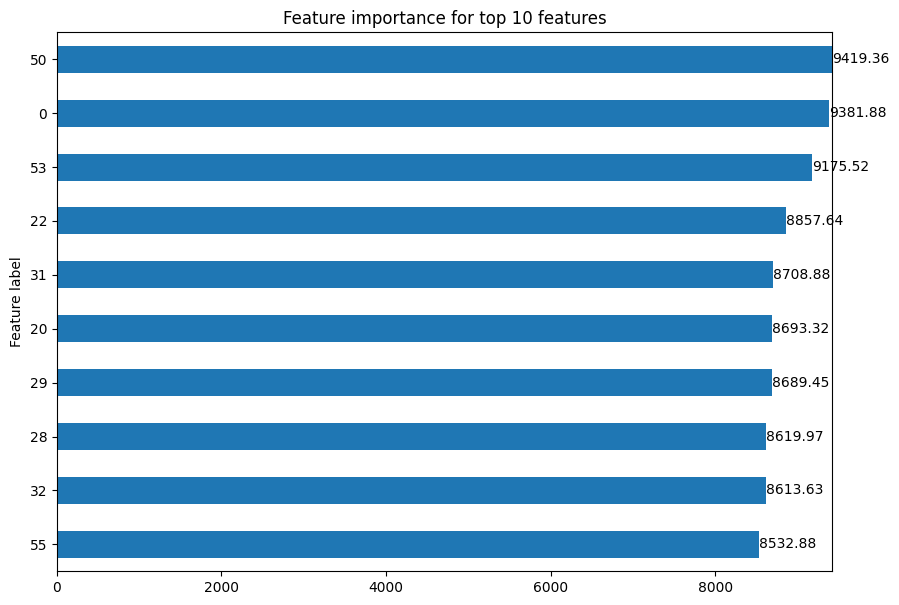

In [22]:
explanation.visualize_feature_importance(top_k=10)

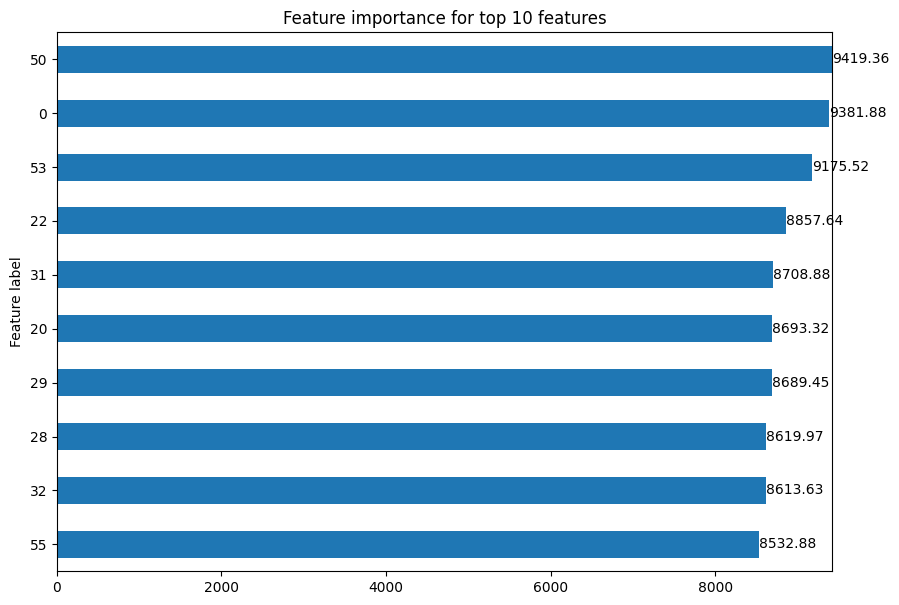

In [21]:
explanation.visualize_feature_importance(top_k=10)